# 10 Pin Repositioning Analysis

**Core question:** if we actually move pins — either to the GPT-4o ground truth location, or to task-specific car/pedestrian entry points — how much does arrival cost improve?

Three sections:
1. **GT repositioning** — for the 392 places flagged should_move, what's the improvement?
2. **Task-specific repositioning** — for the 1,745 dual-labeled places with ≥10m car/pedestrian separation, how much does a mode-specific pin help each type of user?
3. **Combined** — places that both need moving AND have meaningful dual entry points

## Setup

In [1]:
from pathlib import Path
import sys

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.append(str(PROJECT_ROOT))
from src.metrics import haversine_meters

PROCESSED = PROJECT_ROOT / "data" / "processed"

gt  = pd.read_csv(PROCESSED / "ground_truth_combined.csv")
osm = pd.read_csv(PROCESSED / "osm_routing" / "osm_arrival_cost.csv")
mp  = pd.read_csv(PROCESSED / "multipin" / "multipin_pilot.csv")

# Merge OSM routing results into GT
gt  = gt.merge(osm[["id","walk_m","routing_penalty_m","routing_method","osm_arrival_cost_m"]],
               on="id", how="left")

print(f"GT rows:      {len(gt)}")
print(f"Should move:  {gt['should_move'].sum()}")
print(f"Dual-labeled: {len(mp)}")


GT rows:      3425
Should move:  392
Dual-labeled: 2463


## Section 1: GT Repositioning

For the 392 places where the GT says the pin should move, we already know the improvement:
the current `osm_arrival_cost_m` is the cost *before* moving. After moving to the GT pin, cost = 0.
So improvement = `osm_arrival_cost_m`.

In [2]:
movable = gt[gt["should_move"] == True].copy()

# Clip extreme OSRM outliers (>300m = likely routing error, fall back to haversine)
movable["before_cost_m"] = movable["osm_arrival_cost_m"].clip(upper=300)
movable["after_cost_m"]  = 0.0
movable["improvement_m"] = movable["before_cost_m"]

print(f"Places that should move: {len(movable)}")
print()
print("Arrival cost BEFORE repositioning (m):")
print(movable["before_cost_m"].describe().round(2).to_string())
print()
print(f"Total navigation distance eliminated: {movable['improvement_m'].sum():.0f}m")
print(f"Mean improvement per place:           {movable['improvement_m'].mean():.1f}m")
print(f"Median improvement per place:         {movable['improvement_m'].median():.1f}m")


Places that should move: 392

Arrival cost BEFORE repositioning (m):
count    392.00
mean      60.79
std       84.19
min        0.00
25%       13.70
50%       22.40
75%       62.84
max      300.00

Total navigation distance eliminated: 23831m
Mean improvement per place:           60.8m
Median improvement per place:         22.4m


In [3]:
# Improvement by tier
print("Improvement by tier:")
print(movable.groupby("tier_label")["improvement_m"].agg(
    count="count",
    median="median",
    mean="mean",
    total="sum",
).round(1).to_string())
print()
print("Top 15 places with most to gain from repositioning:")
top = movable.sort_values("improvement_m", ascending=False)[
    ["name","category_primary","tier_label","before_cost_m","routing_penalty_m"]
].head(15)
print(top.to_string())


Improvement by tier:
                     count  median  mean    total
tier_label                                       
multi_tenant             3    39.6  89.2    267.5
open_space              68    19.5  38.5   2620.8
standard_commercial    321    23.2  65.2  20942.8

Top 15 places with most to gain from repositioning:
                                          name          category_primary           tier_label  before_cost_m  routing_penalty_m
949                          Metro by T-Mobile        mobile_phone_store  standard_commercial          300.0             595.12
2039                                    Redbox       music_and_dvd_store  standard_commercial          300.0             293.54
453                         Buffalo Wild Wings        chicken_restaurant  standard_commercial          300.0             489.50
2465           Broadway Giant Bagels Mule Road                bagel_shop  standard_commercial          300.0             432.61
1897                                

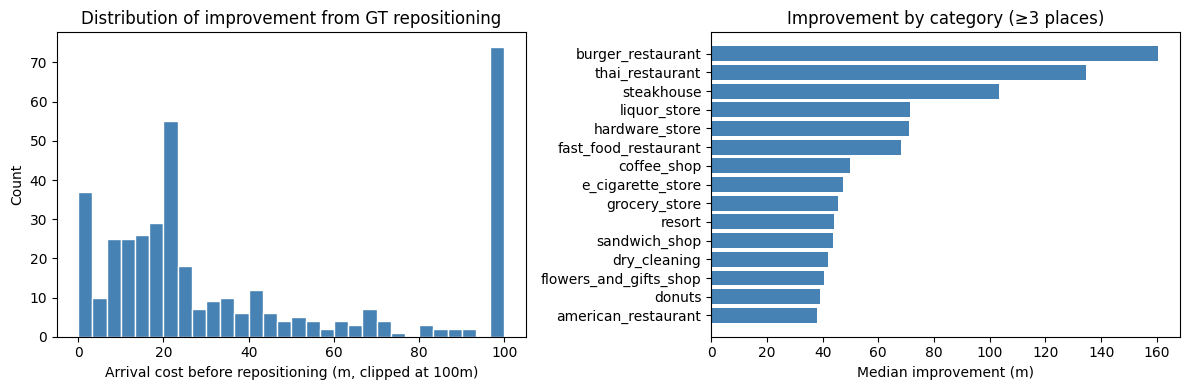

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(movable["before_cost_m"].clip(upper=100), bins=30, color="steelblue", edgecolor="white")
axes[0].set_xlabel("Arrival cost before repositioning (m, clipped at 100m)")
axes[0].set_ylabel("Count")
axes[0].set_title("Distribution of improvement from GT repositioning")

cats = movable.groupby("category_primary")["improvement_m"].agg(count="count", median="median")
cats = cats[cats["count"] >= 3].sort_values("median", ascending=False).head(15)
axes[1].barh(cats.index, cats["median"], color="steelblue")
axes[1].set_xlabel("Median improvement (m)")
axes[1].set_title("Improvement by category (≥3 places)")
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig(PROCESSED / "repositioning" / "repositioning_gt_improvement.png", dpi=150)
plt.show()


## Section 2: Task-Specific Repositioning

For the 2,463 dual-labeled places, we compare two scenarios:

- **Pedestrian-optimised pin** = `pedestrian_entry_lat/lon` — best for walkers/transit
- **Car-optimised pin** = `car_entry_lat/lon` — best for drivers

For each place we compute:
- How far is the current pin from the pedestrian entry? (pedestrian arrival cost with current pin)
- How far is the current pin from the car entry? (driver arrival cost with current pin)
- If we use the pedestrian pin: pedestrian cost → 0, but driver now has to deal with `car_pedestrian_distance_m`
- If we use the car pin: driver cost → 0, but pedestrian cost becomes `car_pedestrian_distance_m`

This shows the trade-off of a single pin vs task-specific pins.

In [5]:
mp = mp.copy()

# Distance from current pin to each entry type (haversine proxy)
mp["current_to_ped_m"] = mp.apply(
    lambda r: haversine_meters(r.current_lat, r.current_lon,
                               r.pedestrian_entry_lat, r.pedestrian_entry_lon), axis=1)
mp["current_to_car_m"] = mp.apply(
    lambda r: haversine_meters(r.current_lat, r.current_lon,
                               r.car_entry_lat, r.car_entry_lon), axis=1)

sep = mp["car_pedestrian_distance_m"]

# Focus on places with meaningful separation
significant = mp[sep >= 10].copy()
print(f"Dual-labeled places with separation ≥ 10m: {len(significant)}")
print()

# With current (single) pin
print("=== CURRENT SINGLE PIN ===")
print(f"Pedestrian arrival cost  — median: {significant['current_to_ped_m'].median():.1f}m  mean: {significant['current_to_ped_m'].mean():.1f}m")
print(f"Driver arrival cost      — median: {significant['current_to_car_m'].median():.1f}m  mean: {significant['current_to_car_m'].mean():.1f}m")
print()

# Scenario A: use pedestrian pin for everyone
ped_pin_ped_cost = 0.0          # pedestrians now land perfectly
ped_pin_car_cost = significant["car_pedestrian_distance_m"]   # drivers now have to walk from ped entry to car entry
print("=== SCENARIO A: Single pedestrian-entry pin ===")
print(f"Pedestrian cost  → 0m (perfect)")
print(f"Driver cost      — median: {ped_pin_car_cost.median():.1f}m  mean: {ped_pin_car_cost.mean():.1f}m")
print()

# Scenario B: use car pin for everyone
car_pin_car_cost = 0.0
car_pin_ped_cost = significant["car_pedestrian_distance_m"]
print("=== SCENARIO B: Single car-entry pin ===")
print(f"Driver cost      → 0m (perfect)")
print(f"Pedestrian cost  — median: {car_pin_ped_cost.median():.1f}m  mean: {car_pin_ped_cost.mean():.1f}m")
print()

# Scenario C: task-specific pins (the right answer)
print("=== SCENARIO C: Task-specific pins (pedestrian pin + car pin) ===")
print(f"Pedestrian cost  → 0m (perfect)")
print(f"Driver cost      → 0m (perfect)")
print(f"This requires serving different coordinates depending on navigation mode.")


Dual-labeled places with separation ≥ 10m: 1745

=== CURRENT SINGLE PIN ===
Pedestrian arrival cost  — median: 0.0m  mean: 4.3m
Driver arrival cost      — median: 21.9m  mean: 27.8m

=== SCENARIO A: Single pedestrian-entry pin ===
Pedestrian cost  → 0m (perfect)
Driver cost      — median: 22.6m  mean: 30.4m

=== SCENARIO B: Single car-entry pin ===
Driver cost      → 0m (perfect)
Pedestrian cost  — median: 22.6m  mean: 30.4m

=== SCENARIO C: Task-specific pins (pedestrian pin + car pin) ===
Pedestrian cost  → 0m (perfect)
Driver cost      → 0m (perfect)
This requires serving different coordinates depending on navigation mode.


In [6]:
# Summary table
summary = pd.DataFrame({
    "Scenario": [
        "Current (single Overture pin)",
        "A: Single pedestrian-entry pin",
        "B: Single car-entry pin",
        "C: Task-specific dual pins",
    ],
    "Pedestrian cost (median m)": [
        significant["current_to_ped_m"].median(),
        0.0,
        significant["car_pedestrian_distance_m"].median(),
        0.0,
    ],
    "Driver cost (median m)": [
        significant["current_to_car_m"].median(),
        significant["car_pedestrian_distance_m"].median(),
        0.0,
        0.0,
    ],
}).round(1)

print(summary.to_string(index=False))


                      Scenario  Pedestrian cost (median m)  Driver cost (median m)
 Current (single Overture pin)                         0.0                    21.9
A: Single pedestrian-entry pin                         0.0                    22.6
       B: Single car-entry pin                        22.6                     0.0
    C: Task-specific dual pins                         0.0                     0.0


In [7]:
# Who does the current pin serve better — pedestrians or drivers?
significant = significant.copy()
significant["current_serves"] = significant.apply(
    lambda r: "pedestrian" if r["current_to_ped_m"] <= r["current_to_car_m"] else "driver",
    axis=1
)
print("Current pin serves better:")
print(significant["current_serves"].value_counts().to_string())
print()
print("By tier:")
print(pd.crosstab(significant["tier_label"], significant["current_serves"]))


Current pin serves better:
current_serves
pedestrian    1521
driver         224

By tier:
current_serves       driver  pedestrian
tier_label                             
multi_tenant              2         161
standard_commercial     222        1360


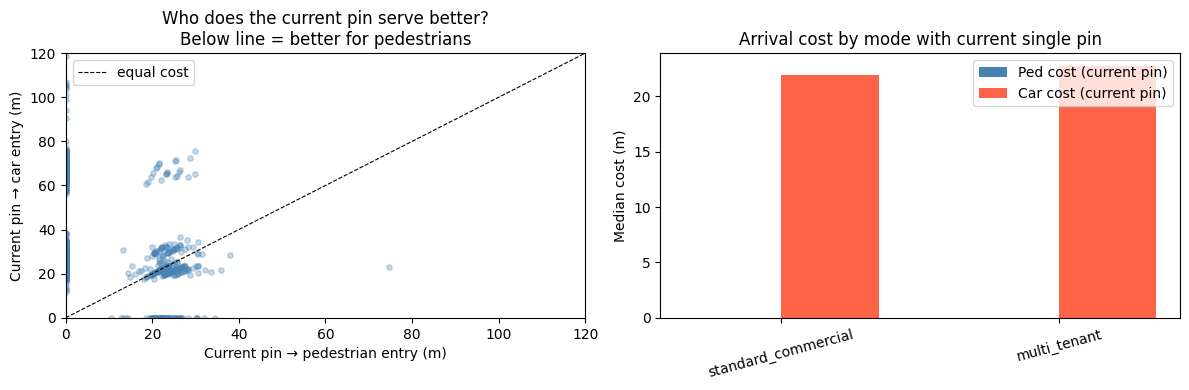

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: scatter current→ped vs current→car
axes[0].scatter(significant["current_to_ped_m"], significant["current_to_car_m"],
                alpha=0.3, s=15, color="steelblue")
axes[0].plot([0,120],[0,120], "k--", linewidth=0.8, label="equal cost")
axes[0].set_xlabel("Current pin → pedestrian entry (m)")
axes[0].set_ylabel("Current pin → car entry (m)")
axes[0].set_title("Who does the current pin serve better?\nBelow line = better for pedestrians")
axes[0].legend()
axes[0].set_xlim(0,120); axes[0].set_ylim(0,120)

# Right: improvement from switching to task-specific pins, by tier
improvement_ped = significant["current_to_ped_m"]
improvement_car = significant["current_to_car_m"]
tiers = significant["tier_label"].unique()
x = range(len(tiers))
w = 0.35
means_ped = [significant[significant["tier_label"]==t]["current_to_ped_m"].median() for t in tiers]
means_car = [significant[significant["tier_label"]==t]["current_to_car_m"].median() for t in tiers]
axes[1].bar([i-w/2 for i in x], means_ped, w, label="Ped cost (current pin)", color="steelblue")
axes[1].bar([i+w/2 for i in x], means_car, w, label="Car cost (current pin)", color="tomato")
axes[1].set_xticks(list(x)); axes[1].set_xticklabels(tiers, rotation=15)
axes[1].set_ylabel("Median cost (m)")
axes[1].set_title("Arrival cost by mode with current single pin")
axes[1].legend()

plt.tight_layout()
plt.savefig(PROCESSED / "repositioning" / "repositioning_task_specific.png", dpi=150)
plt.show()


## Section 3: Places that both should move AND have dual entry points

In [9]:
# Merge multipin data onto the should_move subset
movable_ids = set(gt[gt["should_move"]==True]["id"].astype(str))
mp_movable = mp[mp["id"].astype(str).isin(movable_ids)].copy()

print(f"Should-move places with dual entry labels: {len(mp_movable)}")
print()

if len(mp_movable) > 0:
    print("These places have the clearest case for repositioning:")
    print("- The current pin is measurably wrong (should_move=True)")
    print("- GPT-4o identified distinct car and pedestrian entry points")
    print()
    print(mp_movable[["name","category_primary","tier_label",
                       "car_pedestrian_distance_m","current_to_ped_m","current_to_car_m"
                       ]].sort_values("car_pedestrian_distance_m", ascending=False).to_string())


Should-move places with dual entry labels: 324

These places have the clearest case for repositioning:
- The current pin is measurably wrong (should_move=True)
- GPT-4o identified distinct car and pedestrian entry points

                                                                   name                  category_primary           tier_label  car_pedestrian_distance_m  current_to_ped_m  current_to_car_m
1839              Courtyard by Marriott Titusville Kennedy Space Center                             hotel  standard_commercial                  97.112665         29.794522         75.468107
1002                                                    Chuck E. Cheese                  pizza_restaurant  standard_commercial                  93.416959         28.660664         72.596102
590                                                    SCP Distributors                   wholesale_store  standard_commercial                  87.268340         25.398846         71.563259
40                

In [10]:
# Write summary stats to file
lines = [
    "Pin Repositioning Analysis Summary",
    "",
    f"Places flagged should_move: {len(movable)}",
    f"  Median arrival cost before repositioning: {movable['before_cost_m'].median():.1f}m",
    f"  Mean arrival cost before repositioning:   {movable['before_cost_m'].mean():.1f}m",
    f"  Total navigation distance eliminated:     {movable['improvement_m'].sum():.0f}m",
    "",
    f"Dual-labeled places with separation >= 10m: {len(significant)}",
    f"  Current pin - median pedestrian cost: {significant['current_to_ped_m'].median():.1f}m",
    f"  Current pin - median driver cost:     {significant['current_to_car_m'].median():.1f}m",
    f"  Scenario C (task-specific pins):      0m for both modes",
    f"  Current pin serves pedestrians better in {(significant['current_serves']=='pedestrian').mean()*100:.1f}% of cases",
    "",
    f"Places that should move AND have dual entry: {len(mp_movable)}",
]
(PROCESSED / "repositioning" / "repositioning_summary.txt").write_text("\n".join(lines)+"\n")
print("\n".join(lines))


Pin Repositioning Analysis Summary

Places flagged should_move: 392
  Median arrival cost before repositioning: 22.4m
  Mean arrival cost before repositioning:   60.8m
  Total navigation distance eliminated:     23831m

Dual-labeled places with separation >= 10m: 1745
  Current pin - median pedestrian cost: 0.0m
  Current pin - median driver cost:     21.9m
  Scenario C (task-specific pins):      0m for both modes
  Current pin serves pedestrians better in 87.2% of cases

Places that should move AND have dual entry: 324
